In [42]:
#%pip install matplotlib seaborn

## Librerías

In [43]:
from conexion_bd import obtener_dataframe
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler

## Comprensión de los datos

### Cargado del dataset

In [44]:

df = obtener_dataframe()

Archivo ya existe localmente: data.csv
DataFrame cargado correctamente: 54808 filas x 14 columnas


### Estructura base

In [45]:
df.shape

(54808, 14)

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  str    
 2   region                54808 non-null  str    
 3   education             52399 non-null  str    
 4   gender                54808 non-null  str    
 5   recruitment_channel   54808 non-null  str    
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.9 MB


### Estadísticas Descriptivas (Distribución de los datos)

In [47]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [48]:
df.tail()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,0,78,0
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,0,56,0
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,1,0,79,0
54806,13614,Sales & Marketing,region_9,NaN,m,sourcing,1,29,1.0,2,0,0,45,0
54807,51526,HR,region_22,Bachelor's,m,other,1,27,1.0,5,0,0,49,0


### Descubrimiento de las variables numéricas y categóricas

In [49]:
# Extraer los nombres de las columnas numéricas
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Extraer los nombres de las columnas categóricas
columnas_categoricas = df.select_dtypes(include=['object', 'category', 'bool', 'str']).columns.tolist()
print("Variables Numéricas:")
print(columnas_numericas)
print("\nVariables Categóricas:")
print(columnas_categoricas)

Variables Numéricas:
['employee_id', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'KPIs_met >80%', 'awards_won?', 'avg_training_score', 'is_promoted']

Variables Categóricas:
['department', 'region', 'education', 'gender', 'recruitment_channel']


### Distribución de las variables numéricas

In [50]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


### Distribución de las variables categóricas

In [51]:
def analizar_categoricas(dataframe, columnas):
    print("=== Resumen General de Cardinalidad y Moda ===")
    resumen_cat = []
    
    for col in columnas:
        # Calcular cardinalidad (ignorando nulos por defecto)
        cardinalidad = dataframe[col].nunique()
        
        # Calcular la moda y su frecuencia
        conteo_valores = dataframe[col].value_counts()
        if not conteo_valores.empty:
            moda = conteo_valores.index[0]
            freq_moda = conteo_valores.iloc[0]
            pct_moda = (freq_moda / len(dataframe[col].dropna())) * 100
        else:
            moda, freq_moda, pct_moda = None, 0, 0
            
        resumen_cat.append({
            'Columna': col,
            'Categorías Únicas': cardinalidad,
            'Moda (Top)': moda,
            'Frecuencia Moda': freq_moda,
            '% del Total (Moda)': pct_moda.round(2)
        })
    
    # Mostrar el resumen principal
    resumen_df = pd.DataFrame(resumen_cat).sort_values(by='Categorías Únicas', ascending=False)
    display(resumen_df)
    
    print("\n" + "="*50)
    print("=== Frecuencia Detallada por cada Categoría ===")
    print("="*50)
    
    # Mostrar el detalle de frecuencias absolutas y relativas por cada columna
    for col in columnas:
        print(f"\n👉 Detalle para la columna: '{col}'")
        
        # value_counts(dropna=False) permite ver también si hay datos nulos como una "categoría" más
        conteos = dataframe[col].value_counts(dropna=False)
        porcentajes = dataframe[col].value_counts(normalize=True, dropna=False) * 100
        
        detalle_df = pd.DataFrame({
            'Frecuencia (#)': conteos,
            'Porcentaje (%)': porcentajes.round(2)
        })
        display(detalle_df)
# Ejecutar la función con tus datos
analizar_categoricas(df, columnas_categoricas)

=== Resumen General de Cardinalidad y Moda ===


,Columna,Categorías Únicas,Moda (Top),Frecuencia Moda,% del Total (Moda)
1,region,34,region_2,12343,22.52
0,department,9,Sales & Marketing,16840,30.73
2,education,3,Bachelor's,36669,69.98
4,recruitment_channel,3,other,30446,55.55
3,gender,2,m,38496,70.24



=== Frecuencia Detallada por cada Categoría ===

👉 Detalle para la columna: 'department'


,Frecuencia (#),Porcentaje (%)
department,,
Sales & Marketing,16840,30.73
Operations,11348,20.71
Technology,7138,13.02
Procurement,7138,13.02
Analytics,5352,9.76
Finance,2536,4.63
HR,2418,4.41
Legal,1039,1.90
R&D,999,1.82



👉 Detalle para la columna: 'region'


...

,Frecuencia (#),Porcentaje (%)
education,,
Bachelor's,36669,66.90
Master's & above,14925,27.23
NaN,2409,4.40
Below Secondary,805,1.47



👉 Detalle para la columna: 'gender'


,Frecuencia (#),Porcentaje (%)
gender,,
m,38496,70.24
f,16312,29.76



👉 Detalle para la columna: 'recruitment_channel'


,Frecuencia (#),Porcentaje (%)
recruitment_channel,,
other,30446,55.55
sourcing,23220,42.37
referred,1142,2.08


### Valores faltantes 

In [52]:
# Crear una función para reutilizarla si es necesario
def resumen_datos(dataframe):
    total_filas = len(dataframe)
    
    # Calcular absolutos
    vacios = dataframe.isnull().sum()
    poblados = dataframe.notnull().sum()
    
    # Calcular porcentajes
    pct_vacios = (vacios / total_filas) * 100
    pct_poblados = (poblados / total_filas) * 100
    
    # Estructurar los resultados en un nuevo DataFrame
    resumen_df = pd.DataFrame({
        'Total Registros': total_filas,
        'Poblados (#)': poblados,
        'Poblados (%)': pct_poblados.round(2), # Redondear a 2 decimales
        'Vacíos (#)': vacios,
        'Vacíos (%)': pct_vacios.round(2)
    })
    
    # Ordenar de mayor a menor según la cantidad de vacíos para visualizar los más problemáticos primero
    resumen_df = resumen_df.sort_values(by='Vacíos (#)', ascending=False)
    
    return resumen_df

# Aplicar la función a tu DataFrame 'df'
analisis_columnas = resumen_datos(df)

# Mostrar el resultado (display funciona mejor en Jupyter Notebooks)
display(analisis_columnas)


,Total Registros,Poblados (#),Poblados (%),Vacíos (#),Vacíos (%)
previous_year_rating,54808,50684,92.48,4124,7.52
education,54808,52399,95.60,2409,4.40
department,54808,54808,100.00,0,0.00
region,54808,54808,100.00,0,0.00
gender,54808,54808,100.00,0,0.00
employee_id,54808,54808,100.00,0,0.00
recruitment_channel,54808,54808,100.00,0,0.00
no_of_trainings,54808,54808,100.00,0,0.00
age,54808,54808,100.00,0,0.00
length_of_service,54808,54808,100.00,0,0.00


### Filas duplicadas

In [53]:
filas_duplicadas = df[df.duplicated(keep=False)]
# Ordenar los datos por todas las columnas para que las filas idénticas 
# queden juntas una debajo de la otra, facilitando la lectura visual.
filas_duplicadas = filas_duplicadas.sort_values(by=df.columns.tolist())
print(f"Mostrando el detalle de las {len(filas_duplicadas)} filas involucradas en duplicados:")
# Usar display() para mostrarlo como una tabla bonita en Jupyter
display(filas_duplicadas)

Mostrando el detalle de las 0 filas involucradas en duplicados:


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted


### Detección de valores atípicos

In [54]:
def detectar_outliers_iqr(dataframe, columnas):
    print("=== Detección de Valores Atípicos (Outliers) usando IQR ===")
    
    resumen_outliers = []
    total_filas = len(dataframe)
    
    for col in columnas:
        # Calcular los Cuartiles 1 (25%) y 3 (75%)
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        
        # Calcular el Rango Intercuartílico (IQR)
        IQR = Q3 - Q1
        
        # Definir los límites permitidos (bigotes en un boxplot)
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        
        # Encontrar los valores que están fuera de los límites
        outliers = dataframe[(dataframe[col] < limite_inferior) | (dataframe[col] > limite_superior)]
        cantidad_outliers = len(outliers)
        porcentaje_outliers = (cantidad_outliers / total_filas) * 100
        
        resumen_outliers.append({
            'Columna Numérica': col,
            'Lím. Inferior': round(limite_inferior, 2),
            'Lím. Superior': round(limite_superior, 2),
            '# Outliers': cantidad_outliers,
            '% Outliers': round(porcentaje_outliers, 2)
        })
        
    # Crear un DataFrame con el resumen y ordenarlo por mayor % de outliers
    resumen_df = pd.DataFrame(resumen_outliers).sort_values(by='% Outliers', ascending=False)
    
    display(resumen_df)
    return resumen_df
# Ejecutamos la función sobre nuestras columnas numéricas
tabla_outliers = detectar_outliers_iqr(df, columnas_numericas)

=== Detección de Valores Atípicos (Outliers) usando IQR ===


,Columna Numérica,Lím. Inferior,Lím. Superior,# Outliers,% Outliers
1,no_of_trainings,1.00,1.00,10430,19.03
3,previous_year_rating,1.50,5.50,6223,11.35
8,is_promoted,0.00,0.00,4668,8.52
4,length_of_service,-3.00,13.00,3489,6.37
2,age,14.00,54.00,1435,2.62
6,awards_won?,0.00,0.00,1270,2.32
0,employee_id,-38921.38,117321.62,0,0.00
5,KPIs_met >80%,-1.50,2.50,0,0.00
7,avg_training_score,13.50,113.50,0,0.00


## Visualización de datos

In [55]:
# Configuración visual para que los gráficos se vean profesionales
sns.set_theme(style="whitegrid")
# ==========================================
# 1. VISUALIZACIÓN DE VARIABLES NUMÉRICAS
# ==========================================
def plot_numericas_dist(df, columnas_num):
    print("=== Distribución y Outliers de Variables Numéricas ===")
    for col in columnas_num:
        # Creamos una figura con 2 subgráficos (1 fila, 2 columnas)
        fig, axes = plt.subplots(1, 2, figsize=(15, 4))
        
        # Gráfico 1: Histograma para ver la forma de los datos
        sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue', bins=30)
        axes[0].set_title(f'Histograma de {col} (Distribución)')
        
        # Gráfico 2: Boxplot para ver los Outliers
        sns.boxplot(x=df[col], ax=axes[1], color='lightgreen')
        axes[1].set_title(f'Boxplot de {col} (Outliers)')
        
        plt.tight_layout()
        plt.show()
# ==========================================
# 2. TOP 20 MÁS FRECUENTES (Para Categóricas o Numéricas)
# ==========================================
def plot_top10_frecuencias(df, columnas):
    print("=== Top 10 Valores Más Frecuentes ===")
    
    # Obtenemos el total de registros de la tabla para calcular los porcentajes
    total_registros = len(df)
    
    for col in columnas:
        plt.figure(figsize=(10, 5))
        
        top_10 = df[col].value_counts().nlargest(10)
        x_values = top_10.values
        y_labels = top_10.index.astype(str)
        
        ax = sns.barplot(x=x_values, y=y_labels, palette="viridis", hue=y_labels, legend=False)
        
        for container in ax.containers:
            # Extraemos los valores matemáticos que generó la barra en este contenedor
            valores = container.datavalues
            
            # Construimos la lista de textos personalizados para este contenedor
            etiquetas = []
            for v in valores:
                # v es la cantidad de registros (frecuencia). Validamos que sea > 0 
                # porque internamente seaborn a veces crea contenedores vacíos.
                if v > 0:
                    porcentaje = (v / total_registros) * 100
                    # Formato: Número absoluto \n (Porcentaje%)
                    texto = f"{int(v)}\n({porcentaje:.1f}%)"
                    etiquetas.append(texto)
                else:
                    etiquetas.append("")
                    
            # Le pasamos nuestras etiquetas personalizadas al gráfico
            ax.bar_label(container, labels=etiquetas, padding=5, color='black', fontsize=9)
        
        # Aumentamos el límite X un poco más (25%) porque el texto ahora ocupa más espacio 
        plt.xlim(0, max(x_values) * 1.25)
        
        plt.title(f'Top 10 Frecuencias de: {col}', fontsize=14)
        plt.xlabel('Cantidad de Registros')
        plt.ylabel(col)
        plt.show()
# ==========================================
# 3. MAPA DE CALOR DE CORRELACIONES
# ==========================================
def plot_correlaciones(df, columnas_num):
    print("=== Mapa de Correlación entre Variables Numéricas ===")
    plt.figure(figsize=(10, 8))
    
    # Calculamos la matriz de correlación (Método Pearson por defecto)
    matriz_corr = df[columnas_num].corr()
    
    # Dibujamos el Heatmap
    sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlación Numérica', fontsize=16)
    plt.show()

### Gráficos de columas y boxplot

=== Distribución y Outliers de Variables Numéricas ===


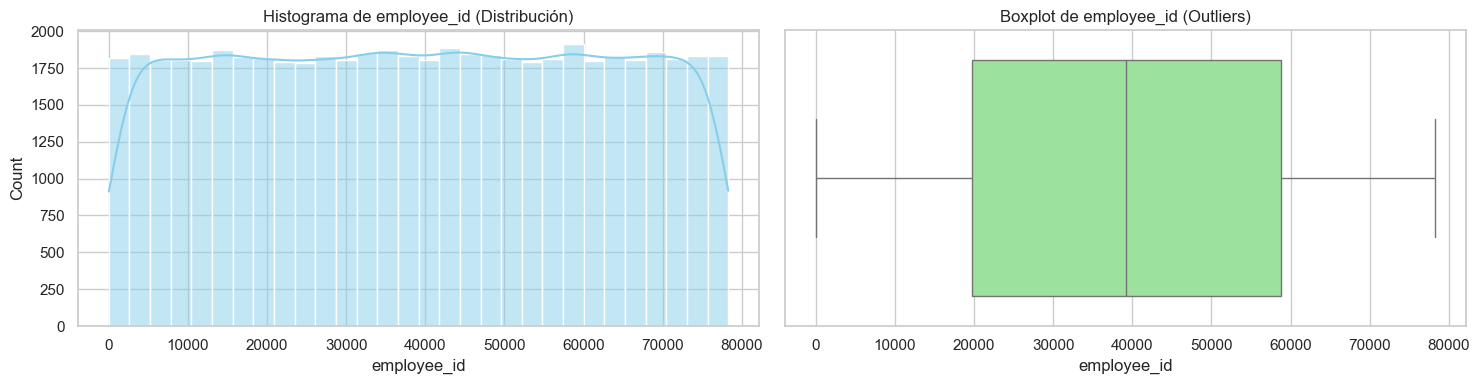

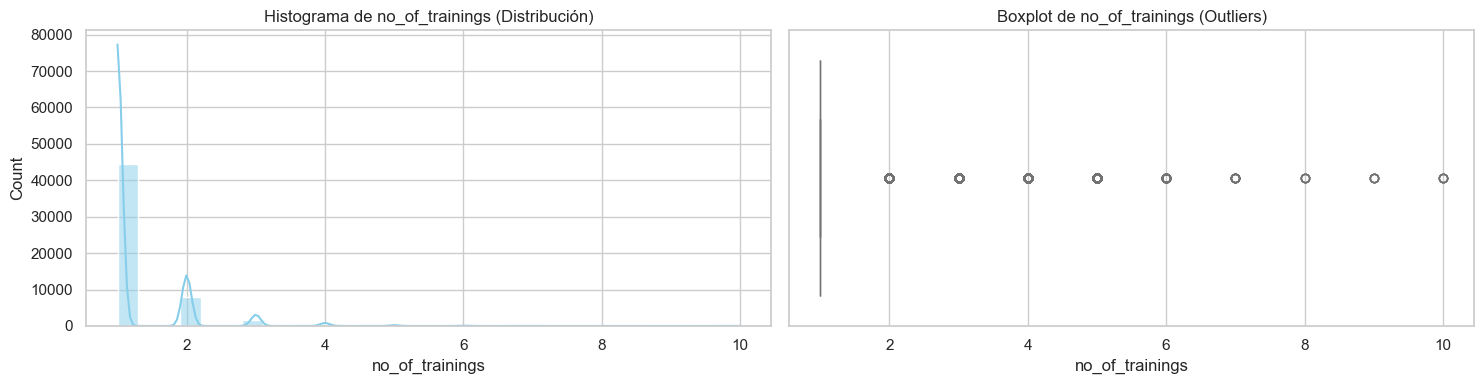

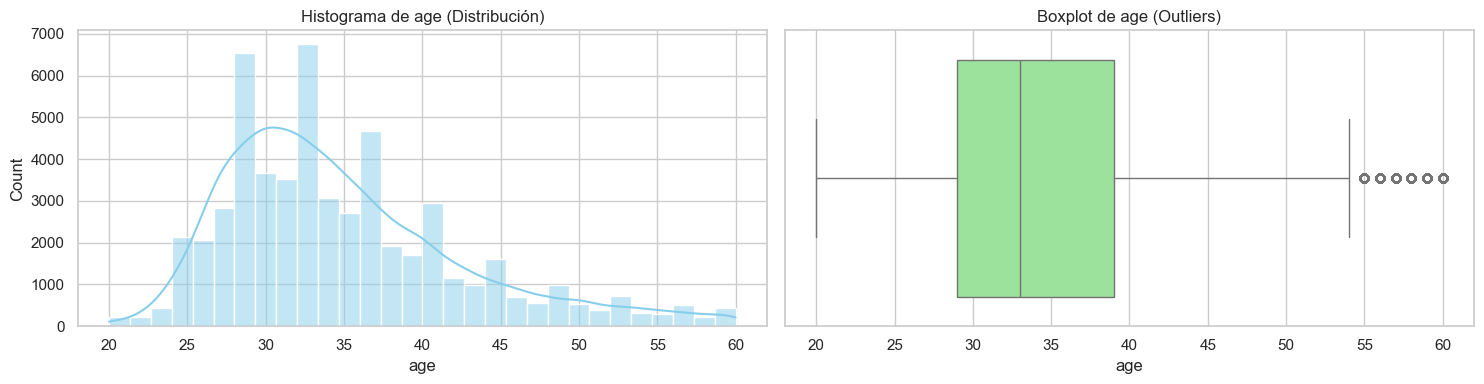

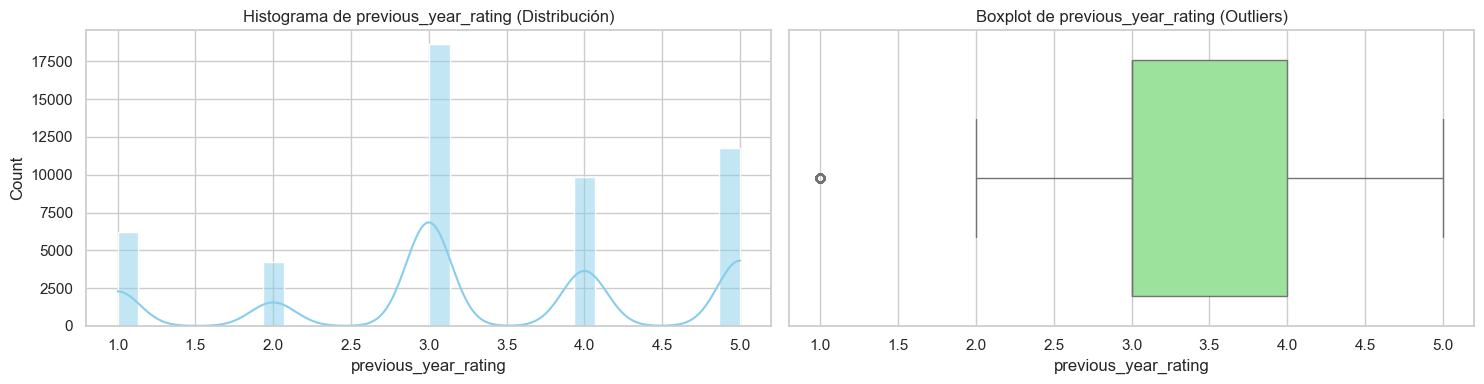

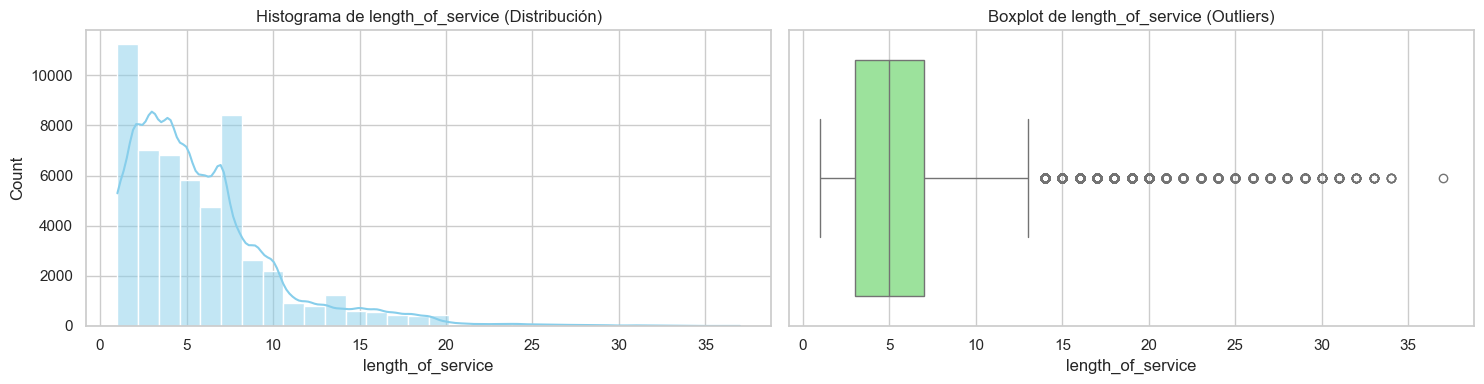

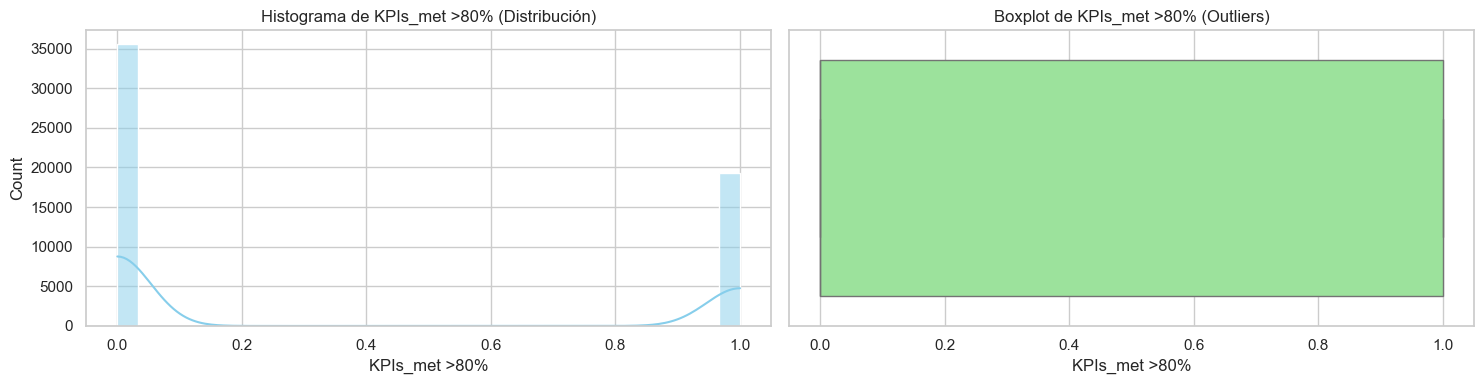

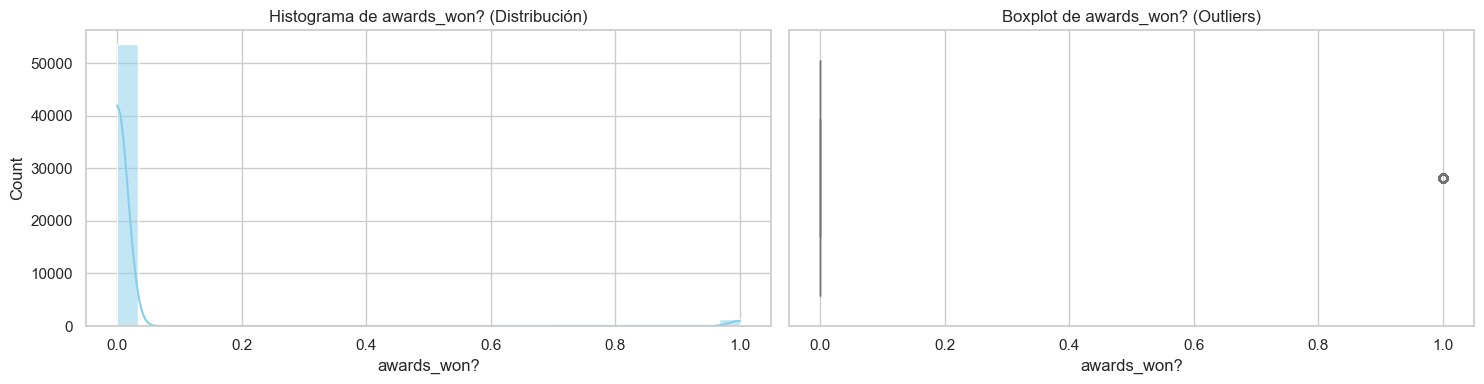

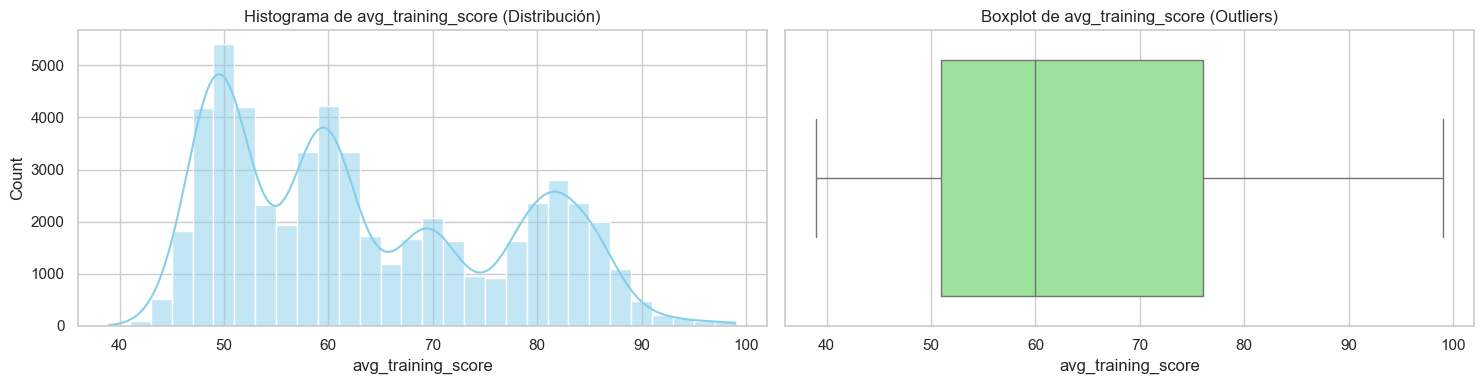

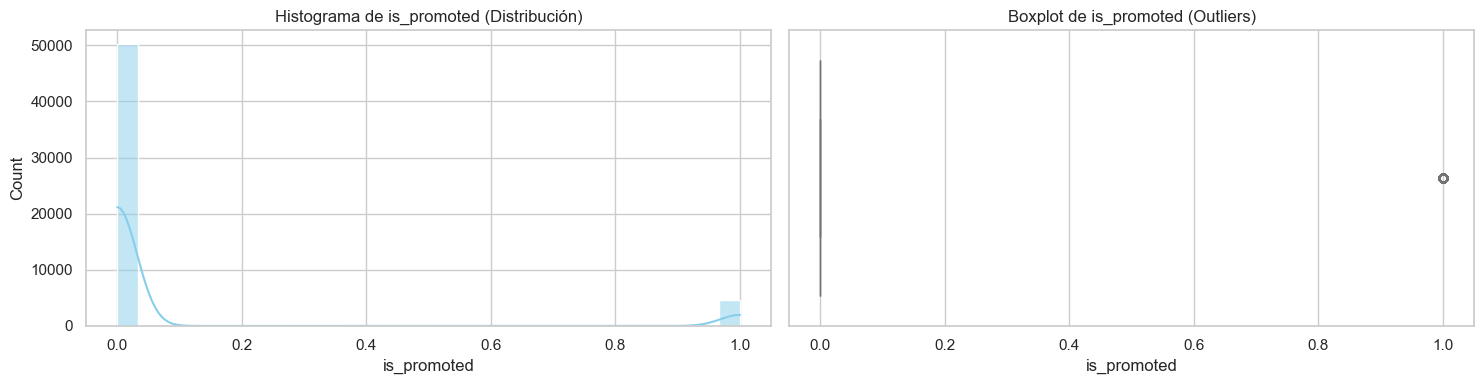

In [56]:
plot_numericas_dist(df, columnas_numericas)

### Gráfico de barras de las variables categóricas (Top 10)

=== Top 10 Valores Más Frecuentes ===


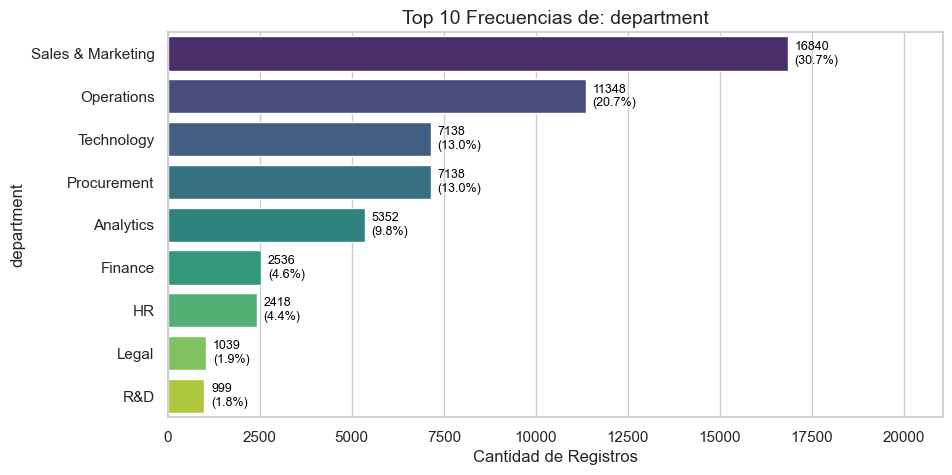

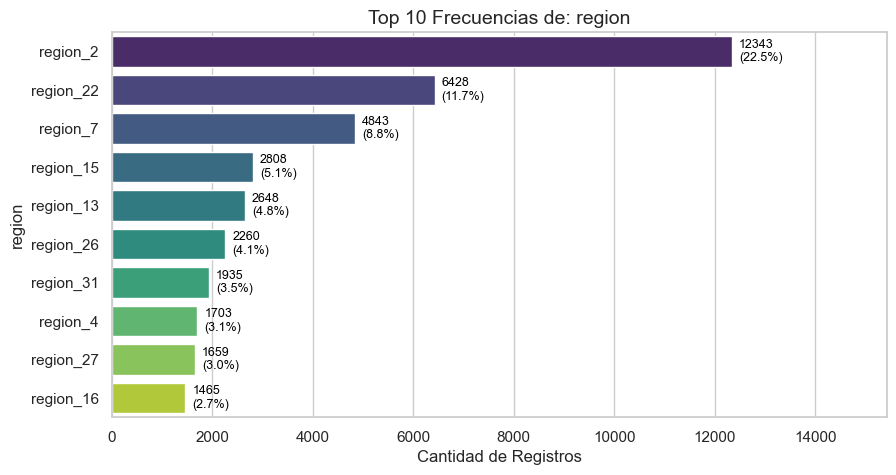

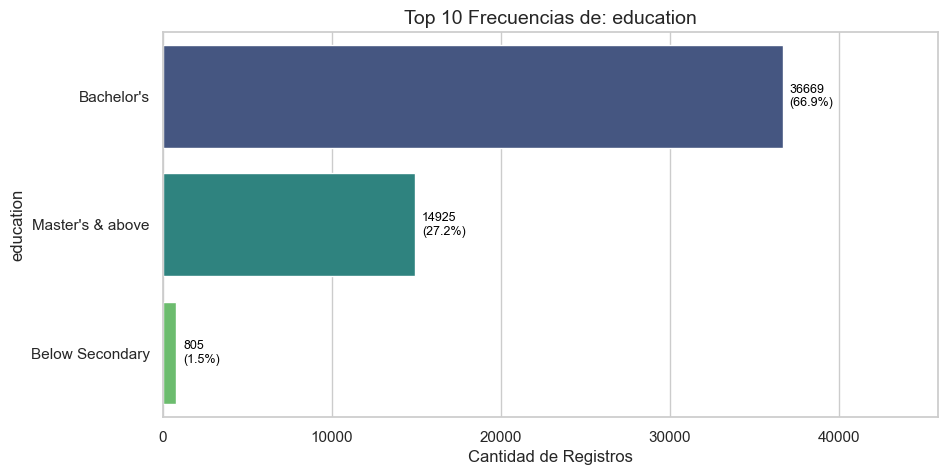

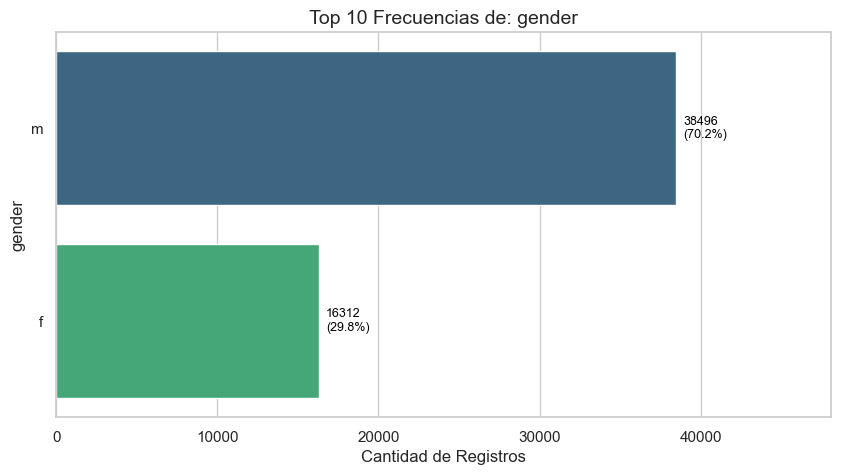

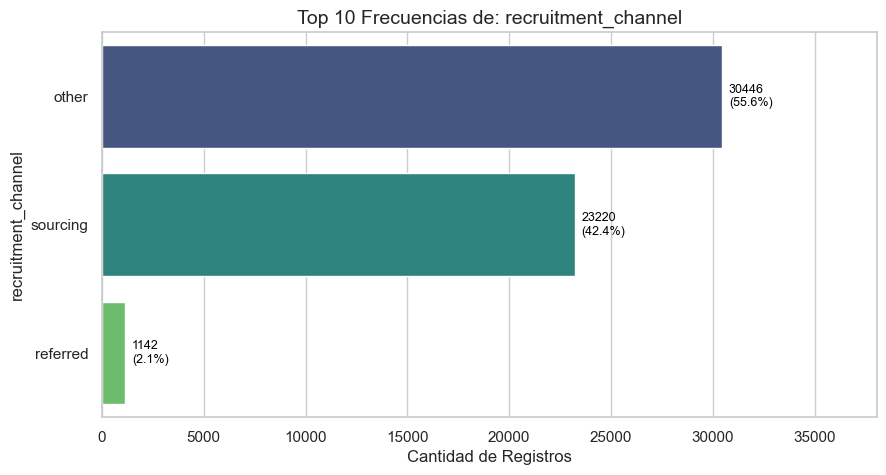

In [57]:
plot_top10_frecuencias(df, columnas_categoricas)  # Top 20 para categóricas

### Gráfico de barras de las variables numéricas (Top 10)

=== Top 10 Valores Más Frecuentes ===


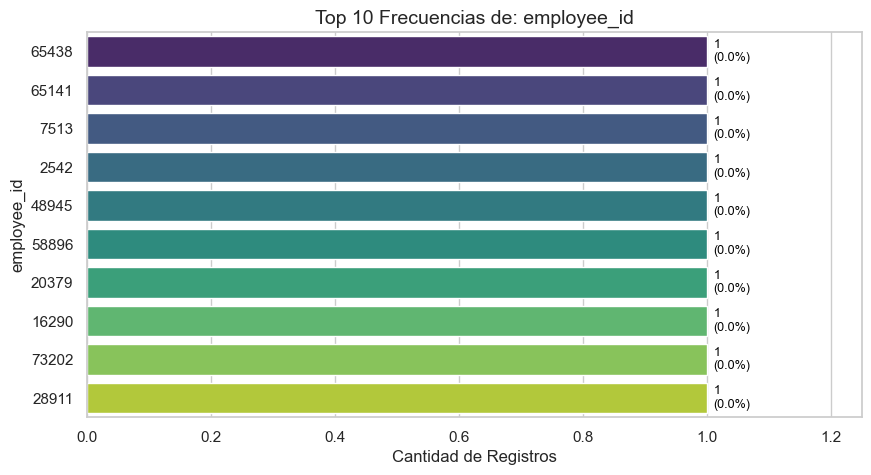

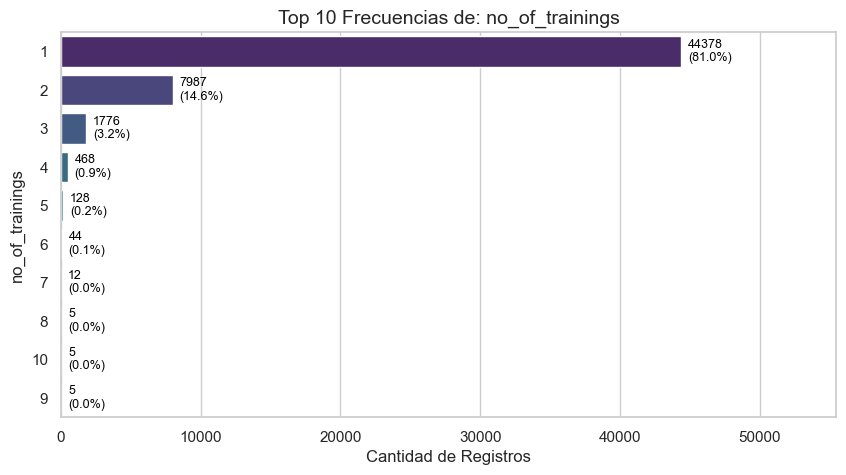

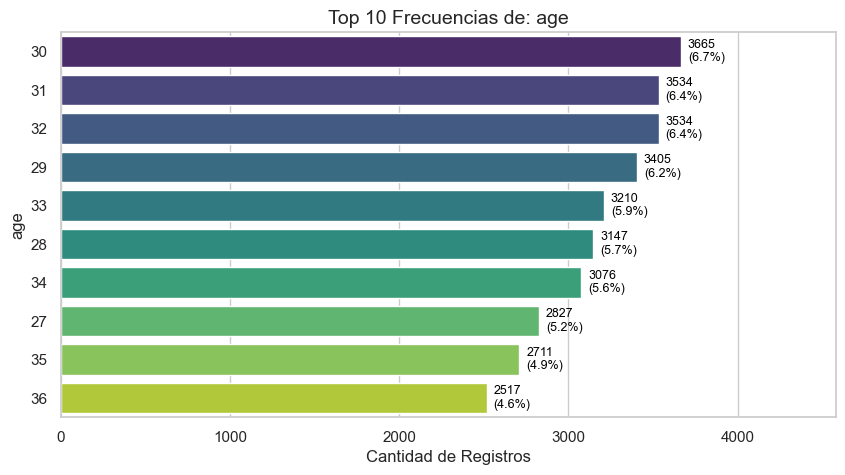

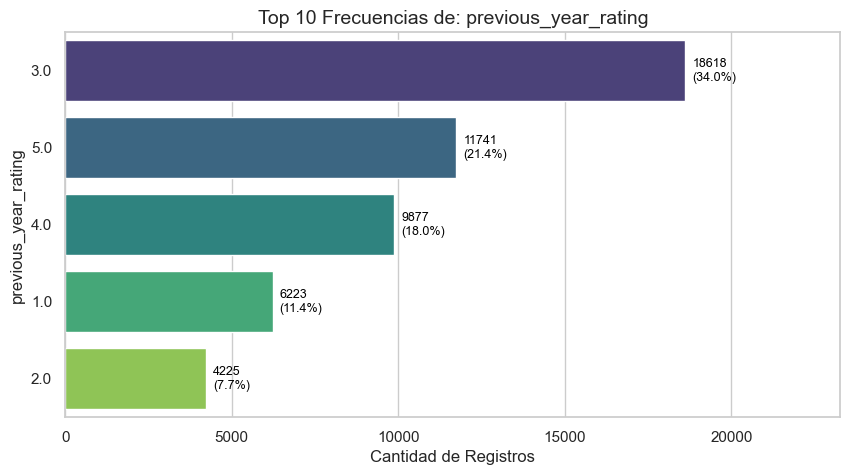

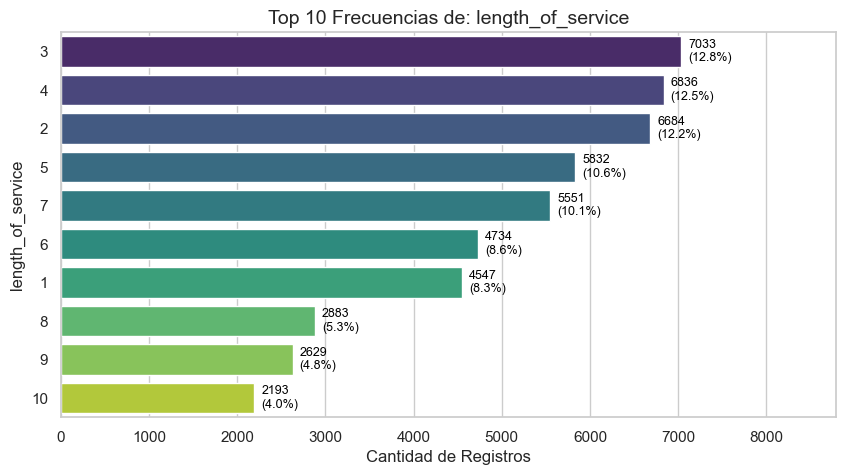

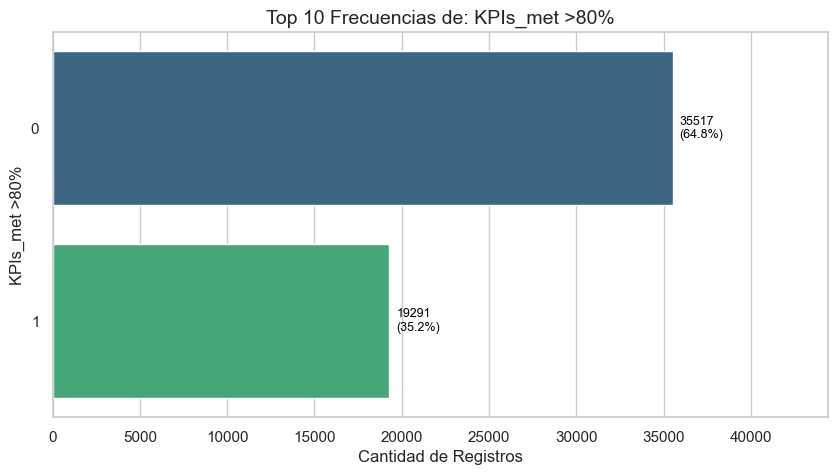

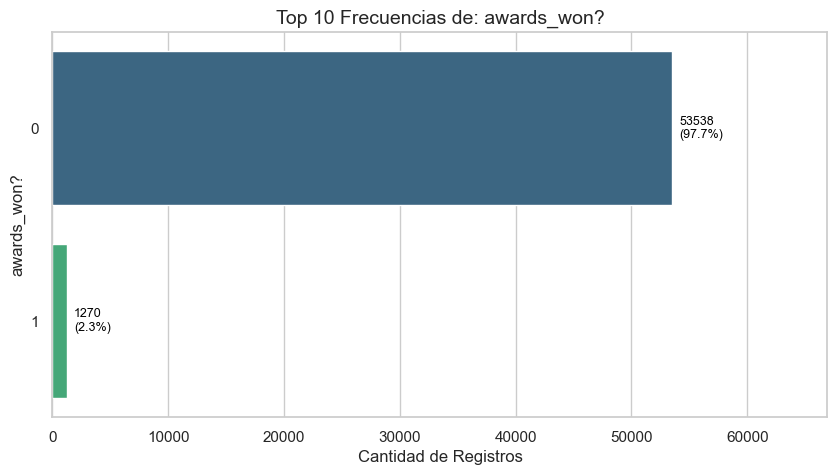

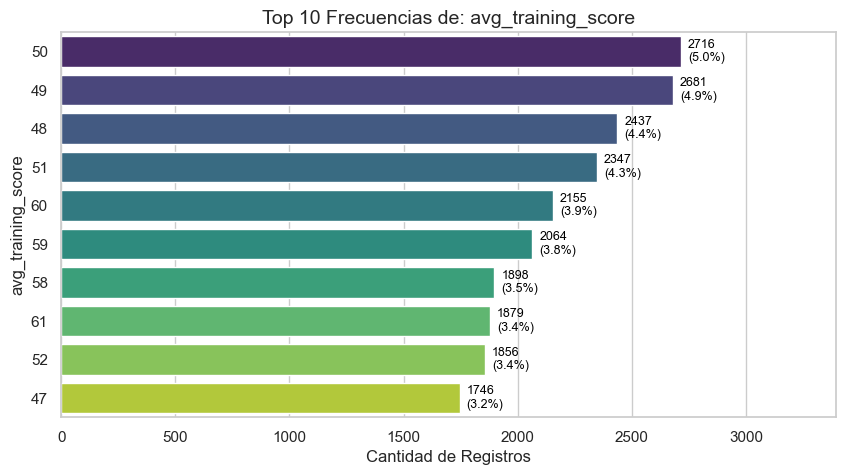

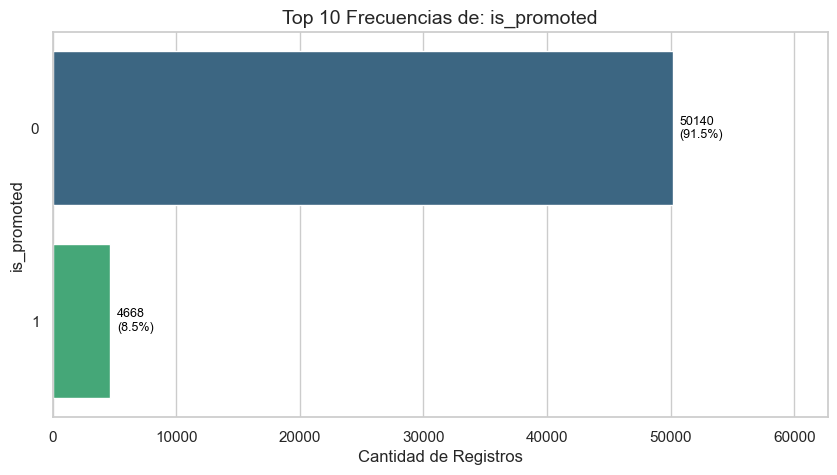

In [58]:
plot_top10_frecuencias(df, columnas_numericas)    # Top 20 para numéricas (como pediste)

### Mapa de Correlación

=== Mapa de Correlación entre Variables Numéricas ===


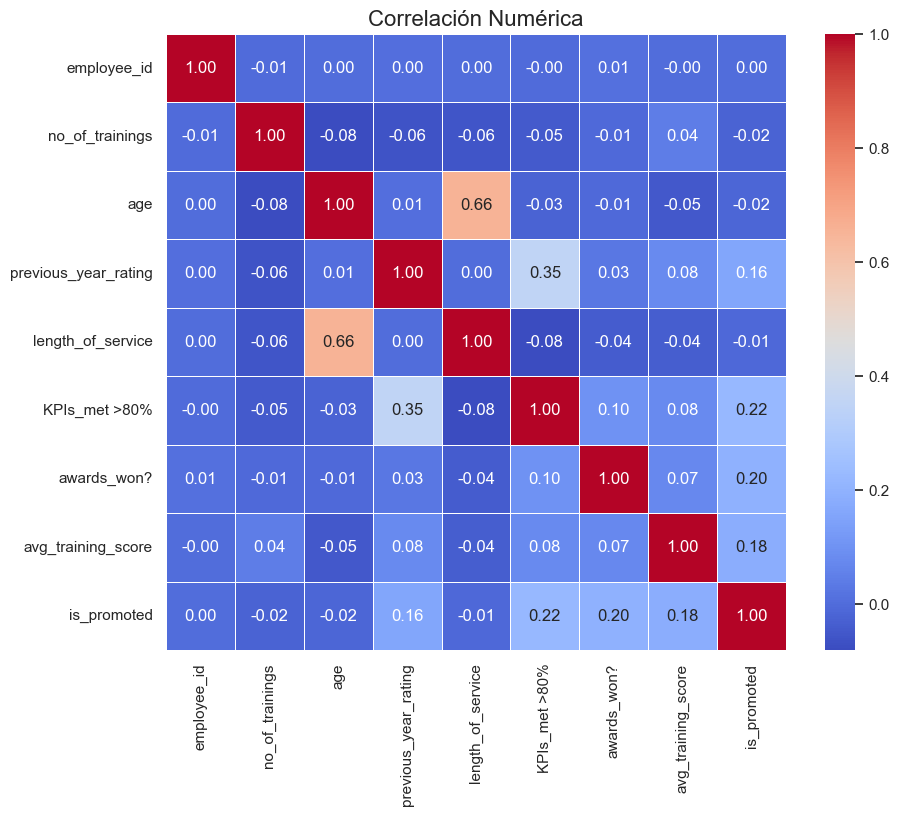

In [59]:
plot_correlaciones(df, columnas_numericas)

### Análisis de las columnas con registros vacíos

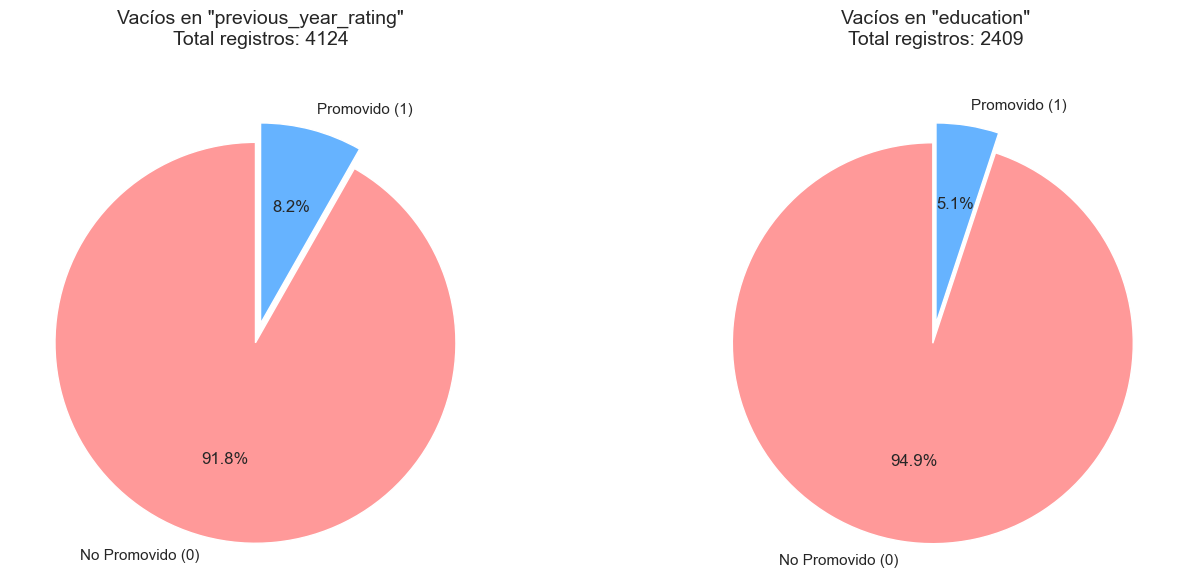

In [60]:
# 1. Filtrar los DataFrames para quedarnos solo con los registros vacíos
df_rating_vacio = df[df['previous_year_rating'].isna()]
df_education_vacio = df[df['education'].isna()]
# 2. Contar la variable objetivo (is_promoted) en esos registros vacíos
conteo_rating = df_rating_vacio['is_promoted'].value_counts()
conteo_education = df_education_vacio['is_promoted'].value_counts()
# Mapeamos los nombres para que el gráfico sea más fácil de leer
etiquetas_rating = ['No Promovido (0)' if i == 0 else 'Promovido (1)' for i in conteo_rating.index]
etiquetas_education = ['No Promovido (0)' if i == 0 else 'Promovido (1)' for i in conteo_education.index]
# 3. Crear los gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # 1 fila, 2 columnas
# --- Gráfico 1: previous_year_rating ---
# Usamos autopct='%1.1f%%' para mostrar el porcentaje con 1 decimal
axes[0].pie(conteo_rating, labels=etiquetas_rating, autopct='%1.1f%%', 
            startangle=90, colors=['#ff9999', '#66b3ff'], explode=(0.1, 0)) # explode separa un poco los trozos
axes[0].set_title(f'Vacíos en "previous_year_rating"\nTotal registros: {len(df_rating_vacio)}', fontsize=14, pad=20)
# --- Gráfico 2: education ---
axes[1].pie(conteo_education, labels=etiquetas_education, autopct='%1.1f%%', 
            startangle=90, colors=['#ff9999', '#66b3ff'], explode=(0.1, 0))
axes[1].set_title(f'Vacíos en "education"\nTotal registros: {len(df_education_vacio)}', fontsize=14, pad=20)
# Ajustar el diseño para que no se sobrepongan
plt.tight_layout()
plt.show()

## Limpieza de datos

### Imputación de valores

Decisión: Mantener los registros vacíos e imputar valores.
¿Por qué?
- Para previous_year_rating: Los valores vacíos pueden significar nuevas contrataciones (su antigüedad en la empresa o length_of_service debe ser de 1 año o menos).

- Para education: Dato demográfico que simplemente el empleado no quiso llenar o Recursos Humanos olvidó registrar. Rellenarlo con la Moda (ej. "Bachelor's") podría sesgar los datos.

In [61]:
# Para la calificación numérica, rellenamos con 0 (indicando 'Sin Evaluación')
df['previous_year_rating'] = df['previous_year_rating'].fillna(0)
# Para la educación, rellenamos con una categoría nueva
df['education'] = df['education'].fillna('Desconocido')

In [62]:
#display(df[['previous_year_rating', 'education']])

## Columnas eliminadas

employee_id:
- Esta columna es un identificador único.
- No aporta absolutamente ninguna capacidad predictiva porque no hay ningún patrón subyacente (el número de ID no determina si eres bueno o malo en tu trabajo).

In [63]:
# Eliminar la columna employee_id (axis=1 significa que borras una columna, no una fila)
#df = df.drop(['employee_id'], axis=1)

#display(df.head(2))

gender y age:
- El sistema debe garantizar recomendaciones basadas estrictamente en méritos académicos y de desempeño.
- Se eliminan estas columnas (variables sensibles) para mitigar cualquier sesgo discriminatorio en el modelo.

In [64]:
# Eliminar las columnas employee_id, gender y age
df = df.drop(['employee_id', 'gender', 'age'], axis=1)

display(df.head(2))

,department,region,education,recruitment_channel,no_of_trainings,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,region_7,Master's & above,sourcing,1,5.0,8,1,0,49,0
1,Operations,region_22,Bachelor's,other,1,5.0,4,0,0,60,0


In [65]:
# Actualizar las listas (limpiar las columnas recién eliminadas)
columnas_numericas = [col for col in columnas_numericas if col not in ['employee_id', 'age', 'is_promoted']]
columnas_categoricas = [col for col in columnas_categoricas if col not in ['gender']]
display(df.head(2))

,department,region,education,recruitment_channel,no_of_trainings,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,region_7,Master's & above,sourcing,1,5.0,8,1,0,49,0
1,Operations,region_22,Bachelor's,other,1,5.0,4,0,0,60,0


# Transformación de datos

Las variables categóricas fueron transformadas mediante One-Hot Encoding para convertir los valores de texto en variables numéricas binarias. Posteriormente, las variables numéricas fueron escaladas utilizando StandardScaler para homogeneizar sus rangos y facilitar el entrenamiento de los modelos de Machine Learning.

In [66]:
categoricas = columnas_categoricas

df = pd.get_dummies(
    df,
    columns=categoricas,
    drop_first=True
)

display(df.head(2))

,no_of_trainings,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted,department_Finance,department_HR,department_Legal,...,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Desconocido,education_Master's & above,recruitment_channel_referred,recruitment_channel_sourcing
0,1,5.0,8,1,0,49,0,False,False,False,...,False,False,True,False,False,False,False,True,False,True
1,1,5.0,4,0,0,60,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# Escalamiento de variables numéricas

Se aplicó StandardScaler a las variables numéricas para estandarizar sus valores. Esto permite que las variables tengan una escala comparable y evita que aquellas con rangos más grandes influyan más en el modelo.

In [67]:
scaler = StandardScaler()

df[columnas_numericas] = scaler.fit_transform(
    df[columnas_numericas]
)

display(df.head(2))

,no_of_trainings,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted,department_Finance,department_HR,department_Legal,...,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Desconocido,education_Master's & above,recruitment_channel_referred,recruitment_channel_sourcing
0,-0.415276,1.283878,0.500460,1.356878,-0.154018,-1.075931,0,False,False,False,...,False,False,True,False,False,False,False,True,False,True
1,-0.415276,1.283878,-0.437395,-0.736986,-0.154018,-0.253282,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# Reducción de datos

Se realizó un análisis de correlación para identificar posibles variables redundantes. Además, se considera la eliminación previa de `employee_id`, ya que era un identificador único y no aportaba capacidad predictiva al modelo.

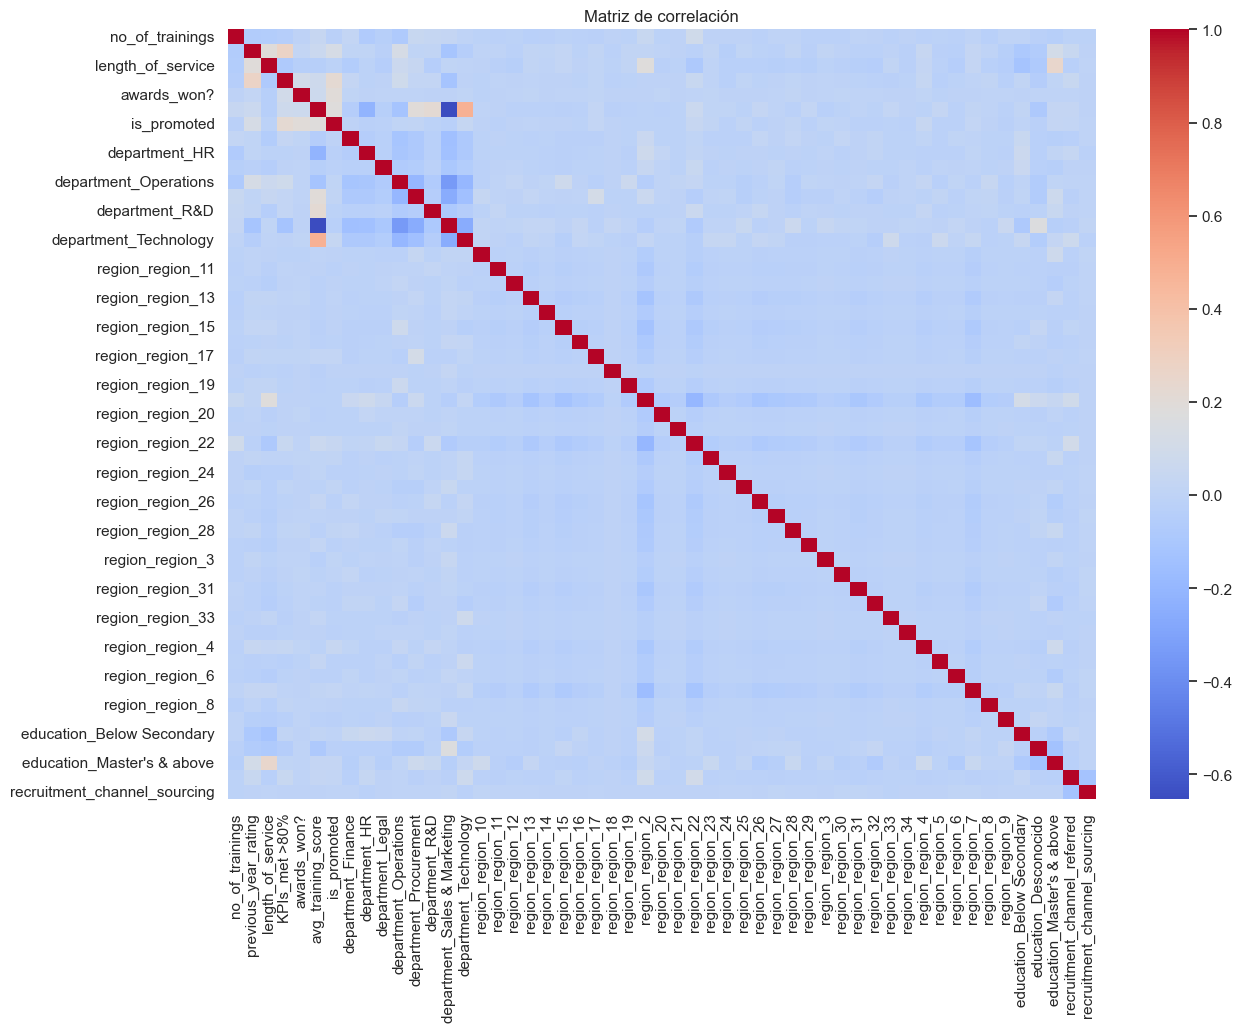

In [68]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Matriz de correlación")
plt.show()

In [69]:
corr_matrix = df.corr().abs()

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.85:
            high_corr.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                )
            )

print(high_corr)

[]


## Conclusión - parte de Transformación

Se realizó un análisis de correlación para identificar posibles relaciones fuertes entre las variables. Los resultados mostraron que no existen pares de variables con correlación superior a 0.85, por lo que no fue necesario eliminar columnas adicionales. Asimismo, se mantuvo la decisión de eliminar la variable `employee_id`, ya que corresponde a un identificador único sin capacidad predictiva para el modelo.

# Modelado

In [ ]:
# 1. Importaciones necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay 
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [107]:
# CONSTANTES GLOBALES 
# ==============================================================================
RANDOM_SEED = 42          # Para asegurar 100% de reproducibilidad
CV_FOLDS = 5              # Número de pliegues para la validación cruzada
TARGET_COL = 'is_promoted' # Nombre de la variable objetivo
TEST_SIZE = 0.2           # Proporción del conjunto de prueba (20%)

In [108]:
def prepare_data(df: pd.DataFrame, target_col: str):
    """
    Separa el conjunto de datos en variables predictoras (X) y variable objetivo (y).
    """
    # Estructura Condicional: Verificamos si la columna objetivo existe
    if target_col in df.columns:
        X = df.drop(columns=[target_col])
        y = df[target_col]
        return X, y
    else:
        raise ValueError(f"La columna objetivo '{target_col}' no se encuentra en el DataFrame.")

In [109]:
def split_data(X: pd.DataFrame, y: pd.Series):
    """
    Realiza la partición de los datos manteniendo la proporción de clases (estratificado).
    """
    # Uso de semilla para control de aleatoriedad
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=TEST_SIZE, 
        random_state=RANDOM_SEED, 
        stratify=y
    )
    return X_train, X_test, y_train, y_test

In [110]:
def build_model(X_train: pd.DataFrame, y_train: pd.Series):
    """
    Construye y optimiza el modelo de Random Forest utilizando RandomizedSearchCV.
    Aplica class_weight='balanced' para compensar el desbalance de clases.
    """
    # Instanciamos el clasificador base con pesos balanceados
    rf_base = RandomForestClassifier(
        class_weight='balanced', 
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    
    # Definimos el espacio de búsqueda (Uso de NumPy arrays)
    param_distributions = {
        'n_estimators': np.arange(50, 301, 10),
        'max_depth': np.arange(3, 16, 1)
    }
    
    # Configuración de validación cruzada estratificada
    cv_stratified = StratifiedKFold(
        n_splits=CV_FOLDS, 
        shuffle=True, 
        random_state=RANDOM_SEED
    )
    
    # Búsqueda aleatoria optimizando 'f1' debido al alto costo de los falsos negativos
    random_search = RandomizedSearchCV(
        estimator=rf_base,
        param_distributions=param_distributions,
        n_iter=15, 
        scoring='f1',
        cv=cv_stratified,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=1
    )
    
    # Flujo Secuencial: Entrenamos el modelo
    print("Iniciando la búsqueda de hiperparámetros...")
    random_search.fit(X_train, y_train)
    print("Entrenamiento completado exitosamente.")
    
    return random_search

In [111]:
def build_lr_model(X_train: pd.DataFrame, y_train: pd.Series):
    """
    Construye y optimiza el modelo de Logistic Regression utilizando RandomizedSearchCV.
    """
    # Instanciamos el clasificador base
    lr_base = LogisticRegression(
        class_weight='balanced', 
        random_state=RANDOM_SEED,
        max_iter=1000 # Aumentamos max_iter porque a veces LR no converge rápido
    )
    
    # Definimos el espacio de búsqueda para C (fuerza de regularización)
    param_distributions = {
        'C': np.logspace(-3, 3, 7) # Valores desde 0.001 hasta 1000
    }
    
    cv_stratified = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    
    random_search = RandomizedSearchCV(
        estimator=lr_base,
        param_distributions=param_distributions,
        n_iter=7, # Solo hay 7 combinaciones posibles aquí
        scoring='f1',
        cv=cv_stratified,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=1
    )
    
    print("Iniciando la búsqueda de hiperparámetros para Regresión Logística...")
    random_search.fit(X_train, y_train)
    print("Entrenamiento de Regresión Logística completado.")
    
    return random_search


In [115]:
def build_svm_model(X_train: pd.DataFrame, y_train: pd.Series):
    """
    Construye y optimiza el modelo de SVM utilizando RandomizedSearchCV.
    """
    # Instanciamos el clasificador base. ¡probability=True es OBLIGATORIO aquí!
    svm_base = SVC(
        class_weight='balanced', 
        random_state=RANDOM_SEED,
        probability=True 
    )
    
    # Espacio de búsqueda reducido (SVM tarda mucho en entrenar)
    param_distributions = {
        'C': [1]
    }
    
    
    random_search = RandomizedSearchCV(
        estimator=svm_base,
        param_distributions=param_distributions,
        n_iter=1, # 3 valores de C * 2 kernels = 6 iteraciones
        scoring='f1',
        cv=2,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=1
    )
    
    print("Iniciando la búsqueda de hiperparámetros para SVM (Esto puede tardar varios minutos)...")
    random_search.fit(X_train, y_train)
    print("Entrenamiento de SVM completado.")
    
    return random_search


In [116]:
def evaluate_model(model, X_test: pd.DataFrame, y_test: pd.Series, threshold: float = 0.5):
    """
    Evalúa el mejor modelo utilizando métricas clave y calibración de umbral.
    """
    # Extraemos el mejor modelo entrenado
    best_rf = model.best_estimator_
    
    # Predecimos usando probabilidades para calibrar el corte (Calibración de Umbral)
    y_pred_proba = best_rf.predict_proba(X_test)[:, 1]
    
    # Aplicamos el umbral personalizado
    y_pred_custom = (y_pred_proba >= threshold).astype(int)
    
    # Cálculo de métricas
    accuracy = accuracy_score(y_test, y_pred_custom)
    precision = precision_score(y_test, y_pred_custom)
    recall = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print("\n" + "="*50)
    print("RESULTADOS DE LA OPTIMIZACIÓN (Top 3 configuraciones):")
    results = pd.DataFrame(model.cv_results_)
    top_results = results.sort_values(by='rank_test_score').head(3)
    
    for index, row in top_results.iterrows():
        print(f"Ranking: {row['rank_test_score']} | F1-Score: {row['mean_test_score']:.4f} | Params: {row['params']}")
    print("="*50 + "\n")
    
    # Mostramos los resultados finales
    print("EVALUACIÓN DEL MEJOR MODELO EN EL CONJUNTO DE PRUEBA")
    print(f"Mejores Hiperparámetros: {model.best_params_}")
    print(f"Umbral de decisión utilizado: {threshold} (Probabilidad)")
    print("-" * 50)
    print(f"Exactitud (Accuracy)  : {accuracy:.4f}")
    print(f"Precisión (Precision) : {precision:.4f}")
    print(f"Sensibilidad (Recall) : {recall:.4f}")
    print(f"F1-Score              : {f1:.4f}")
    print(f"ROC-AUC               : {roc_auc:.4f}")
    print("-" * 50)
    print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_custom))
    
    # =========================================================
    # NUEVO CÓDIGO: Gráficos de Matriz de Confusión
    # =========================================================
    class_names = ['No Promovido', 'Promovido'] # Etiquetas más descriptivas
    titles_options = [
        ("Matriz de Confusión (Sin Normalizar)", None),
        ("Matriz de Confusión (Normalizada)", "true"),
    ]
    
    for title, normalize in titles_options:
        disp = ConfusionMatrixDisplay.from_predictions(
            y_test, 
            y_pred_custom, # <-- Usamos tus predicciones personalizadas basadas en el umbral
            display_labels=class_names,
            cmap=plt.cm.Blues,
            normalize=normalize,
        )
        disp.ax_.set_title(title)

         # --- SOLUCIÓN: Desactivar la cuadrícula (grid) heredada ---
        disp.ax_.grid(False) 
        
    # Mostramos ambas figuras juntas al final del proceso
    plt.show()


--- INICIANDO PIPELINE DE MACHINE LEARNING ---
Dimensiones de entrenamiento: X=(43846, 52), y=(43846,)
Dimensiones de prueba: X=(10962, 52), y=(10962,)


1️⃣ ENTRENANDO MODELO PRINCIPAL: RANDOM FOREST
Iniciando la búsqueda de hiperparámetros...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Entrenamiento completado exitosamente.

RESULTADOS DE LA OPTIMIZACIÓN (Top 3 configuraciones):
Ranking: 1 | F1-Score: 0.3652 | Params: {'n_estimators': np.int64(260), 'max_depth': np.int64(15)}
Ranking: 2 | F1-Score: 0.3650 | Params: {'n_estimators': np.int64(210), 'max_depth': np.int64(15)}
Ranking: 3 | F1-Score: 0.3477 | Params: {'n_estimators': np.int64(50), 'max_depth': np.int64(13)}

EVALUACIÓN DEL MEJOR MODELO EN EL CONJUNTO DE PRUEBA
Mejores Hiperparámetros: {'n_estimators': np.int64(260), 'max_depth': np.int64(15)}
Umbral de decisión utilizado: 0.4 (Probabilidad)
--------------------------------------------------
Exactitud (Accuracy)  : 0.6962
Precisión (Precision) : 0.2095
Sen

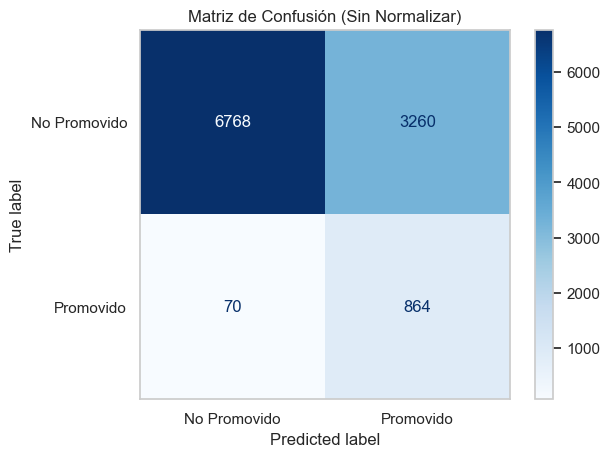

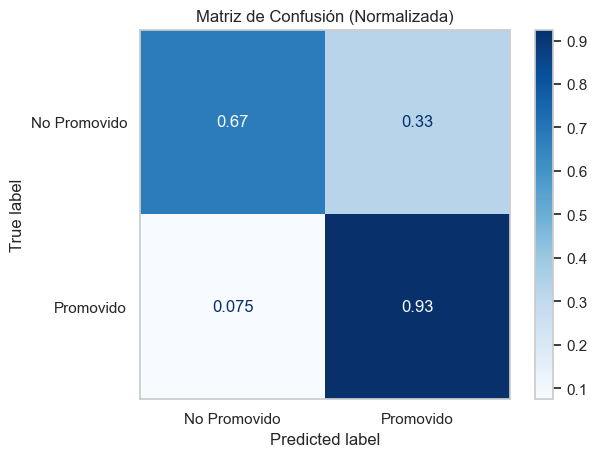


2️⃣ ENTRENANDO MODELO DE COMPARACIÓN: REGRESIÓN LOGÍSTICA
Iniciando la búsqueda de hiperparámetros para Regresión Logística...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Entrenamiento de Regresión Logística completado.

RESULTADOS DE LA OPTIMIZACIÓN (Top 3 configuraciones):
Ranking: 1 | F1-Score: 0.3710 | Params: {'C': np.float64(100.0)}
Ranking: 2 | F1-Score: 0.3709 | Params: {'C': np.float64(1000.0)}
Ranking: 3 | F1-Score: 0.3706 | Params: {'C': np.float64(1.0)}

EVALUACIÓN DEL MEJOR MODELO EN EL CONJUNTO DE PRUEBA
Mejores Hiperparámetros: {'C': np.float64(100.0)}
Umbral de decisión utilizado: 0.4 (Probabilidad)
--------------------------------------------------
Exactitud (Accuracy)  : 0.7240
Precisión (Precision) : 0.2219
Sensibilidad (Recall) : 0.8929
F1-Score              : 0.3554
ROC-AUC               : 0.8761
--------------------------------------------------

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0

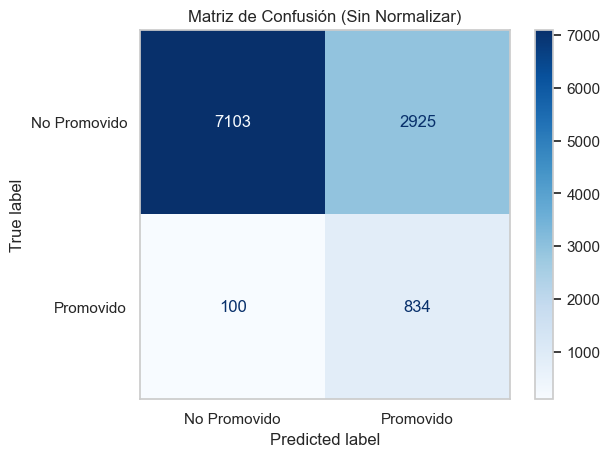

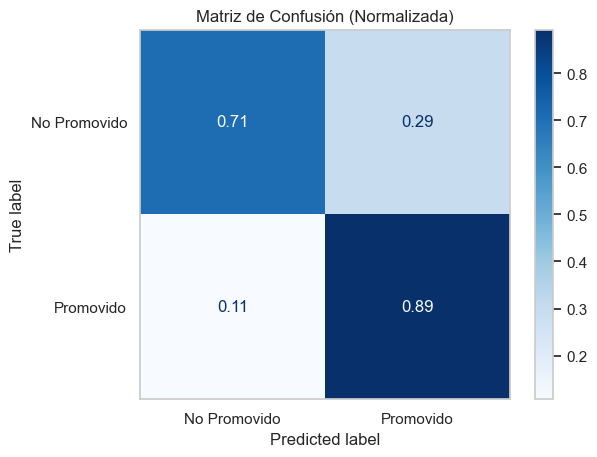


3️⃣ ENTRENANDO MODELO DE COMPARACIÓN: SVM
Iniciando la búsqueda de hiperparámetros para SVM (Esto puede tardar varios minutos)...
Fitting 2 folds for each of 1 candidates, totalling 2 fits


c:\Users\mauri\Repositorios\ML_TF\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Entrenamiento de SVM completado.

RESULTADOS DE LA OPTIMIZACIÓN (Top 3 configuraciones):
Ranking: 1 | F1-Score: 0.3653 | Params: {'C': 1}

EVALUACIÓN DEL MEJOR MODELO EN EL CONJUNTO DE PRUEBA
Mejores Hiperparámetros: {'C': 1}
Umbral de decisión utilizado: 0.4 (Probabilidad)
--------------------------------------------------
Exactitud (Accuracy)  : 0.9269
Precisión (Precision) : 0.8037
Sensibilidad (Recall) : 0.1884
F1-Score              : 0.3053
ROC-AUC               : 0.8776
--------------------------------------------------

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96     10028
           1       0.80      0.19      0.31       934

    accuracy                           0.93     10962
   macro avg       0.87      0.59      0.63     10962
weighted avg       0.92      0.93      0.91     10962



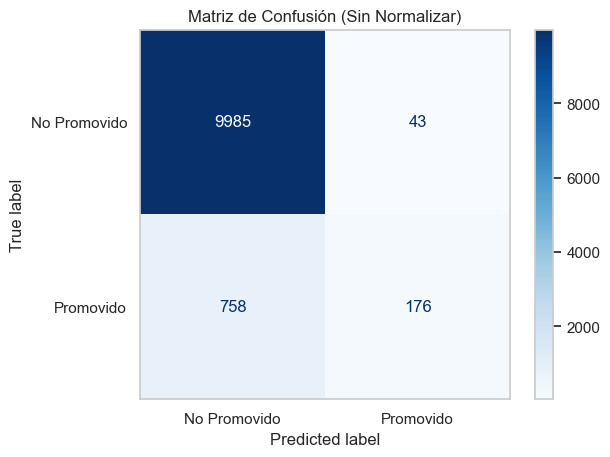

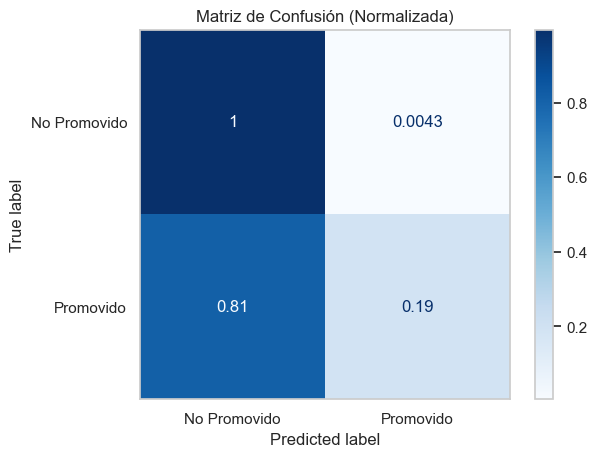

In [117]:
# Estructura Condicional de flujo principal
if __name__ == "__main__":
    # Aseguramos que el dataframe 'df' se encuentra cargado previamente en el notebook
    if 'df' in locals() or 'df' in globals():
        
        print("--- INICIANDO PIPELINE DE MACHINE LEARNING ---")
        # Tu 'df' ya está completamente limpio, escalado y con variables dummy.
        # Recordando que TARGET_COL = 'is_promoted'
        
        # 1. Preparación de los datos (Cambiamos df_model a df)
        X, y = prepare_data(df, TARGET_COL)
        
        # 2. Partición Estratificada
        X_train, X_test, y_train, y_test = split_data(X, y)
        print(f"Dimensiones de entrenamiento: X={X_train.shape}, y={y_train.shape}")
        print(f"Dimensiones de prueba: X={X_test.shape}, y={y_test.shape}\n")
        
        
        # ==============================================================
        # 3. MODELO PRINCIPAL: Random Forest (Optimizado)
        # ==============================================================
        print("\n" + "="*50)
        print("1️⃣ ENTRENANDO MODELO PRINCIPAL: RANDOM FOREST")
        print("="*50)
        random_search_model = build_model(X_train, y_train)
        
        if random_search_model is not None:
            # Umbral de 0.4 para priorizar el Recall
            evaluate_model(random_search_model, X_test, y_test, threshold=0.4)
        else:
            print("Error grave: El modelo Random Forest no se pudo entrenar.")
            
            
        # ==============================================================
        # 4. MODELO DE COMPARACIÓN 1: Regresión Logística
        # ==============================================================
        print("\n" + "="*50)
        print("2️⃣ ENTRENANDO MODELO DE COMPARACIÓN: REGRESIÓN LOGÍSTICA")
        print("="*50)
        lr_search_model = build_lr_model(X_train, y_train)
        
        if lr_search_model is not None:
            # Usamos el mismo umbral de 0.4 para tener una comparación justa
            evaluate_model(lr_search_model, X_test, y_test, threshold=0.4)
        else:
            print("Error grave: El modelo de Regresión Logística no se pudo entrenar.")
            
            
        # ==============================================================
        # 5. MODELO DE COMPARACIÓN 2: Support Vector Machine (SVM)
        # ==============================================================
        print("\n" + "="*50)
        print("3️⃣ ENTRENANDO MODELO DE COMPARACIÓN: SVM")
        print("="*50)
        svm_search_model = build_svm_model(X_train, y_train)
        
        if svm_search_model is not None:
            # Usamos el mismo umbral de 0.4 para tener una comparación justa
            evaluate_model(svm_search_model, X_test, y_test, threshold=0.4)
        else:
            print("Error grave: El modelo SVM no se pudo entrenar.")
            
    else:
        print("El DataFrame 'df' no está definido. Asegúrese de ejecutar la celda de carga de datos previamente.")


# Pruebas

In [6]:
import pandas as pd

# 1. Definir los resultados extraídos de las pruebas en Test (Umbral 0.4)
resultados_test = {
    'Métrica': [
        'Exactitud (Accuracy)', 
        'Precisión (Clase 1)', 
        'Sensibilidad (Recall)', 
        'Puntaje F1 (F1-Score)', 
        'ROC-AUC'
    ],
    'Random Forest': [0.6962, 0.2095, 0.9251, 0.3416, 0.8816],
    'Regresión Logística': [0.7240, 0.2219, 0.8929, 0.3554, 0.8761],
    'SVM': [0.9269, 0.8037, 0.1884, 0.3053, 0.8776]
}

# 2. Crear el DataFrame
df_modelos = pd.DataFrame(resultados_test)

# 3. Ajustar el formato para presentación
df_modelos.set_index('Métrica', inplace=True)

# 4. Mostrar la tabla formateada en Markdown
print("Tabla Comparativa de Rendimiento de Modelos (Test Set)")
print("=" * 76)
print(df_modelos.to_markdown())
print("=" * 76)

Tabla Comparativa de Rendimiento de Modelos (Test Set)
| Métrica               |   Random Forest |   Regresión Logística |    SVM |
|:----------------------|----------------:|----------------------:|-------:|
| Exactitud (Accuracy)  |          0.6962 |                0.724  | 0.9269 |
| Precisión (Clase 1)   |          0.2095 |                0.2219 | 0.8037 |
| Sensibilidad (Recall) |          0.9251 |                0.8929 | 0.1884 |
| Puntaje F1 (F1-Score) |          0.3416 |                0.3554 | 0.3053 |
| ROC-AUC               |          0.8816 |                0.8761 | 0.8776 |
